In [1]:
# main.py
import numpy as np
import gym
#from DDPG_trial import DDPG
from collections import deque
import pdb
import pandas as pd
import torch
from env import env
from LSTM import LSTMModel  
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
np.random.seed(42)
import pdb 
M, N, J = 10, 4, 3
# Replay Buffer for Experience Replay
class ReplayBuffer:
    def __init__(self, max_size=int(1e6)):
        self.buffer = deque(maxlen=max_size)

    def add(self, state, next_state, action, reward):
        self.buffer.append((state, next_state, action, reward))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, next_state, action, reward = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state),
            torch.FloatTensor(next_state),
            torch.FloatTensor(action),
            torch.FloatTensor(reward).unsqueeze(1),
            #torch.FloatTensor(done).unsqueeze(1),
        )

    def size(self):
        return len(self.buffer)

###########generate random discrete matrix for actions(should ideally come from the discretization procedure)


def generate_matrix(N, J):
    # Initialize an NxJ matrix filled with zeros
    matrix = np.zeros((N, J), dtype=int)
    
    # Ensure each column has at least one 1
    for j in range(J):
        # Randomly select a row to place the 1 in column j
        while True:
            row_index = np.random.randint(N)
            # Place the 1 only if that row currently contains no 1
            if np.sum(matrix[row_index]) == 0:
                matrix[row_index, j] = 1
                break
    
    # Fill remaining rows with either a single 1 or all 0s
    for i in range(N):
        if np.sum(matrix[i]) == 0:  # If the row is all zeros
            if np.random.rand() > 0.5:  # 50% chance to add a 1
                col_index = np.random.randint(J)
                matrix[i, col_index] = 1
    
    return matrix


In [2]:
#model = torch.load('LSTM.pth')
# Initialize the model architecture
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Model parameters
input_dim = N
hidden_dim = 128
output_dim = N
num_layers = 1

# Initialize the model, loss function and optimizer
model = LSTMModel(input_dim, hidden_dim, output_dim, num_layers).to(device)
#model = LSTMModel()  # Initialize your model with the required parameters

# Load the saved state dictionary
model.load_state_dict(torch.load('LSTM_state_dict_50k.pth'))


C:\Users\sriniva3\AppData\Local\Temp\ipykernel_15888\3206326457.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('LSTM_state_dict_50k.pt

<All keys matched successfully>

In [3]:
Ts = 50000
environ = env(Ts = Ts, N = N, M = M, J= J )
alltime_fast_fading_gains, ff_gains = environ.fast_fading_channel_coefficients()
TxRxds = environ.compute_TxRX()
alltime_PathGains = environ.large_scale_fading_channel_coefficients(TxRxds)


#### save ####
#np.save('alltime_fast_fading_gains.npy', alltime_fast_fading_gains)
#np.save('ff_gains.npy', ff_gains)
#np.save('TxRxds.npy', TxRxds)
#np.save('alltime_PathGains.npy',alltime_PathGains)


#### load ####
'''
alltime_fast_fading_gains = np.load('alltime_fast_fading_gains_50k.npy')
ff_gains = np.load('ff_gains_50k.npy')
TxRxds = np.load('TxRxds_50k.npy')
alltime_PathGains = np.load('alltime_PathGains_50k.npy')
'''

100%|██████████████████████████████████████████████████████████████████████████| 49999/49999 [00:13<00:00, 3829.46it/s]


"\nalltime_fast_fading_gains = np.load('alltime_fast_fading_gains_50k.npy')\nff_gains = np.load('ff_gains_50k.npy')\nTxRxds = np.load('TxRxds_50k.npy')\nalltime_PathGains = np.load('alltime_PathGains_50k.npy')\n"

In [4]:
pwd

'C:\\Users\\sriniva3\\OneDrive - Aalto University\\Simulations\\from git base codes\\April22_2025\\base-codes-main\\base-codes-main\\X_subnets_MADRL_two_agents'

In [5]:
TimeVaris = np.arange(0,5,5/Ts)
len(TimeVaris)

50000

In [6]:
pwd

'C:\\Users\\sriniva3\\OneDrive - Aalto University\\Simulations\\from git base codes\\April22_2025\\base-codes-main\\base-codes-main\\X_subnets_MADRL_two_agents'

In [7]:
def get_lstm_pred_SINR(ts_start, ts_end, b = None, interfers_actions = None, flag = None, b_actions = None):
    history = 10
    SINR_nxt_lstm = np.zeros((J,N))
    for j in range(J):
        inp = []
        for ts in np.arange(ts_start, ts_end):
            SINR =  environ.get_next_state(alltime_PathGains, alltime_fast_fading_gains, ts = ts, b = b, interfers_actions = interfers_actions,
                                          flag = flag, b_actions = b_actions)[0]
            inp.append(SINR[:,j])
        inp = np.array(inp).reshape(1,history,N)
        SINR_nxt_lstm[j,:] = model(torch.Tensor(inp)).detach().numpy()[0]
    SINR_nxt_lstm = np.transpose(SINR_nxt_lstm)
    return SINR_nxt_lstm


In [8]:
'''
b_prev_actions =  generate_matrix(N, J)
state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
b_prsnt_actions =  generate_matrix(N, J)
nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
'''

'\nb_prev_actions =  generate_matrix(N, J)\nstate_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)\nstate = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)\nb_prsnt_actions =  generate_matrix(N, J)\nnxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)\nnext_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)\n'

In [9]:
# Actor Network
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128,64)
        self.fc4 = nn.Linear(64, action_dim)
        self.max_action = max_action

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = torch.sigmoid(self.fc4(x))
        return x * self.max_action

# Critic Network
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, state, action):
        x = torch.cat([state, action], 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_value = F.relu(self.fc3(x))
        #pdb.set_trace()
        return q_value

In [10]:
# DDPG Agent
class DDPG:
    def __init__(self, state_dim, action_dim, max_action):
        self.actor = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target = Actor(state_dim, action_dim, max_action).to(torch.device("cpu"))
        self.actor_target.load_state_dict(self.actor.state_dict())
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=0.5e-3)

        self.critic = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target = Critic(state_dim, action_dim).to(torch.device("cpu"))
        self.critic_target.load_state_dict(self.critic.state_dict())
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=0.5e-3)

        self.max_action = max_action
        self.discount = 0.99
        self.tau = 0.005

    def select_action(self, state):
        state = torch.FloatTensor(state.reshape(1, -1)).to(torch.device("cpu"))
        action = self.actor(state).cpu().data.numpy().flatten()
        return action

    def train(self, replay_buffer, t, batch_size=64):
        # Sample a batch of transitions from the replay buffer
        state, next_state, action, reward = replay_buffer.sample(batch_size)
        next_state = next_state.view(batch_size,-1)
        state = state.view(batch_size,-1)
        action = action.view(batch_size,-1)
        # Compute the target Q value
        #pdb.set_trace()
        next_action = self.actor_target(next_state)
        target_q = self.critic_target(next_state, next_action)
        #target_q1, target_q2 = self.critic_target(next_state, next_action)
        #target_q = torch.min(target_q1, target_q2)
        if t < 256:
            not_done = 1.0
        else:
            not_done = 0.0
        #pdb.set_trace()
        target_q = reward + not_done * self.discount * target_q.detach()

        # Get current Q estimate
        current_q = self.critic(state, action)
        #current_q1, current_q2 = self.critic(state, action)
        #current_q = torch.min(current_q1, current_q2)
        # Compute critic loss
        critic_loss = F.mse_loss(current_q, target_q)

        # Optimize the critic
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # Compute actor loss
        actor_loss = -self.critic(state, self.actor(state)).mean()

        # Optimize the actor
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

        # Update the target networks
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

        for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

In [11]:
######### get binary discretized action #########

def return_bin_descrete_action(N,J,uhat):
    u = np.zeros((N,J))
    
    def select_unique_max_indices(matrix):
        
        selected_rows = set()  # To track used row indices
        result_indices = []
    
        # Iterate through each column
        for j in range(J):
            # Sort the row indices by the column values in descending order
            sorted_row_indices = np.argsort(matrix[:, j])[::-1]
            
            # Find the first available row index that has not been selected
            for row in sorted_row_indices:
                if row not in selected_rows:
                    selected_rows.add(row)
                    result_indices.append((row, j))
                    break
        
        return result_indices

    max_indices = select_unique_max_indices(uhat)
    
    # Display the result
    #print(uhat)
    #print("Selected (row, column) indices:", max_indices)
    
    allocated_resos = []
    for ind in max_indices:
        u[ind[0],ind[1]] = 1.0
        allocated_resos.extend([ind[0]])
    unallocated_resos = np.array([r for r in range(N) if r not in allocated_resos])
    
    
    v = np.concatenate((np.zeros((1,J)), np.eye(J)))
    
    
    for r in unallocated_resos:
        ind = np.argmin([np.linalg.norm(uhat[r,:] - v[n,:]) for n in range(v.shape[0])])
        u[r,:] = v[ind,:]
    return u

In [12]:
T = 256
############# get initial states  #############
'''
b_prev_actions =  generate_matrix(N, J)
state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
b_prsnt_actions =  generate_matrix(N, J)
nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
'''
############################################################
state_dim = 2*N*J
action_dim = N*J
max_action = 1.0
time_slots = np.arange(0,Ts)

agent = DDPG(state_dim, action_dim, max_action)
agent2 = DDPG(state_dim, action_dim, max_action)

replay_buffer = ReplayBuffer()
replay_buffer2 = ReplayBuffer()

#train_agents(env, agent1, agent2, replay_buffer)
episodes=200
batch_size=128

ts_counter = 0

######## generate interactions dummy ###########
interfers_actions = np.zeros((M-1, J, N)) # should be the actions from other agent. 
for i, m in enumerate(range(M-1)):
    interfers_actions[i,:,:] = np.transpose(generate_matrix(N, J))

In [13]:
epi_rewards = []
epi_rewards2 = []
b_prev_actions =  generate_matrix(N, J)
b_prev_actions2 =  generate_matrix(N, J)

P_e = []
P_e2 = []
for episode in range(episodes):
        ############# get initial states  #############
        if episode == 0:
            state_lstm = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)
            state_lstm2 = get_lstm_pred_SINR(ts_start = 0, ts_end = 10)

        else:
            state_lstm = get_lstm_pred_SINR(ts_start = ts_counter, ts_end = ts_counter+10)
            state_lstm2 = get_lstm_pred_SINR(ts_start = ts_counter, ts_end = ts_counter+10)
        #state = np.stack((np.multiply(state_lstm, b_prev_actions),b_prev_actions), axis = 0)
        state = np.stack((state_lstm,b_prev_actions), axis = 0)
        state2 = np.stack((state_lstm2,b_prev_actions2), axis = 0)
        #b_prsnt_actions =  generate_matrix(N, J)
        #nxt_state_lstm = get_lstm_pred_SINR(ts_start = 1, ts_end = 11)
        #next_state = np.stack((np.multiply(nxt_state_lstm, b_prsnt_actions),b_prsnt_actions), axis = 0)
        ############################################################
        episode_reward = 0
        episode_reward2 = 0
        for t in range(T):
            action = agent.select_action(np.array(state))
            action2 = agent2.select_action(np.array(state2))
            action = return_bin_descrete_action(N,J,np.reshape(action,(N,J)))
            action2 = return_bin_descrete_action(N,J,np.reshape(action2,(N,J)))
            #action =  (action >= 0.5).astype(float)
            #next_state, reward, done, _ = env.step(action)
            #pdb.set_trace()
            #print(episode,t)
            nxt_state_lstm = get_lstm_pred_SINR(ts_start = ts_counter+1, ts_end = ts_counter + 11, 
                                                b = 1, interfers_actions = np.concatenate((action2.reshape(1,J,N), interfers_actions[1:,:,:])),
                                                b_actions = b_prev_actions)
            nxt_state_lstm2 = get_lstm_pred_SINR(ts_start = ts_counter+1, ts_end = ts_counter + 11,
                                                b = 0, interfers_actions = np.concatenate((action.reshape(1,J,N), interfers_actions[1:,:,:])),
                                                b_actions = b_prev_actions2)

            #next_state = np.stack((np.multiply(nxt_state_lstm, action.reshape(N,J)),action.reshape(N,J)), axis = 0)
            next_state = np.stack((nxt_state_lstm,action.reshape(N,J)), axis = 0)
            next_state2 = np.stack((nxt_state_lstm2,action2.reshape(N,J)), axis = 0)
            
            state = next_state
            state2 = next_state2
            #reward = np.sum(environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    #b = 0, interfers_actions = interfers_actions, b_actions = b_prev_actions)[2])
            #pdb.set_trace()
            interfers_actions[0,:,:], interfers_actions[1,:,:] = action2.reshape(J,N), action.reshape(J,N)
            
            
            _, p_e, reward = environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    b = 0, interfers_actions = np.concatenate((action2.reshape(1,J,N), interfers_actions[1:,:,:])), b_actions = b_prev_actions)
            _, p_e2, reward2 = environ.compute_rewards(alltime_PathGains, alltime_fast_fading_gains, ts = time_slots[ts_counter + 10],
                                                    b = 1, interfers_actions = np.concatenate((action.reshape(1,J,N), interfers_actions[1:,:,:])), b_actions = b_prev_actions2)
            
            P_e.append(p_e)
            P_e2.append(p_e2)
            
            reward = np.sum(reward)
            reward2 = np.sum(reward2)
            
            #print(t, p_e, reward)
            episode_reward += reward
            episode_reward2 += reward2
            
            replay_buffer.add(state, next_state, action.reshape(N,J), reward)
            replay_buffer2.add(state2, next_state2, action2.reshape(N,J), reward2)

            if replay_buffer.size() > batch_size:
                agent.train(replay_buffer, t, batch_size)
            if replay_buffer2.size() > batch_size:
                agent2.train(replay_buffer2, t, batch_size)
            ts_counter+=1
            if ts_counter == Ts - 10:
                ts_counter = 0
            #print(ts_counter)
        b_prev_actions = action.reshape(N,J)
        b_prev_actions2 = action2.reshape(N,J)
        
        print(f"Episode: {episode + 1}, Reward: {episode_reward/256}")
        print(f"Episode: {episode + 1}, Reward: {episode_reward2/256}")
        
        epi_rewards.append(episode_reward/256)
        epi_rewards2.append(episode_reward2/256)

Episode: 1, Reward: -1.6702876571106935
Episode: 1, Reward: 1.2711933719835586
Episode: 2, Reward: 5.24463362286303
Episode: 2, Reward: -3.336431198339178
Episode: 3, Reward: 12.348147539953885
Episode: 3, Reward: 0.3735969391532995
Episode: 4, Reward: 8.561907747449188
Episode: 4, Reward: -0.49586820968380674
Episode: 5, Reward: 8.017535311789919
Episode: 5, Reward: -0.9114283787115637
Episode: 6, Reward: 6.867396734952181
Episode: 6, Reward: -4.82696526757738
Episode: 7, Reward: 19.763396197489197
Episode: 7, Reward: -3.7488155303877555
Episode: 8, Reward: 17.385557309750187
Episode: 8, Reward: -4.5951516291184875
Episode: 9, Reward: 19.121107547524247
Episode: 9, Reward: -7.254074939692656
Episode: 10, Reward: 14.69459895457793
Episode: 10, Reward: -2.9449142560733677
Episode: 11, Reward: 14.407397093815625
Episode: 11, Reward: -0.4400136809725105
Episode: 12, Reward: 17.033511245387796
Episode: 12, Reward: 0.22430658919725857
Episode: 13, Reward: 17.510361495671738
Episode: 13, Rew

Episode: 105, Reward: 29.32243670029755
Episode: 105, Reward: 29.612687515618973
Episode: 106, Reward: 30.7440118490428
Episode: 106, Reward: 29.077521714665565
Episode: 107, Reward: 23.640692388083227
Episode: 107, Reward: 28.618742494490828
Episode: 108, Reward: 24.056712678638842
Episode: 108, Reward: 24.893819545699824
Episode: 109, Reward: 28.50180545112253
Episode: 109, Reward: 34.05898716563924
Episode: 110, Reward: 28.14481536215859
Episode: 110, Reward: 30.107878635097375
Episode: 111, Reward: 23.908052050307884
Episode: 111, Reward: 26.823294412813453
Episode: 112, Reward: 26.924744518842147
Episode: 112, Reward: 30.17451124065911
Episode: 113, Reward: 33.32340135394641
Episode: 113, Reward: 30.251821702906206
Episode: 114, Reward: 33.77866071895119
Episode: 114, Reward: 29.714217985081802
Episode: 115, Reward: 28.724776560194154
Episode: 115, Reward: 29.696948058678363
Episode: 116, Reward: 29.127231873666346
Episode: 116, Reward: 27.163913106968636
Episode: 117, Reward: 25.

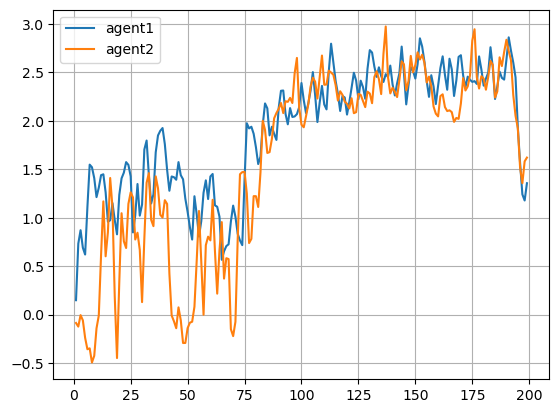

In [14]:
r1 = pd.Series(np.array(epi_rewards)/(N*J))
r2 = pd.Series(np.array(epi_rewards2)/(N*J))
r1 = r1.rolling(window=2).mean()
r2 = r2.rolling(window=2).mean()
plt.plot(r1, label = 'agent1')
plt.plot(r2, label = 'agent2')
plt.legend()
plt.grid()

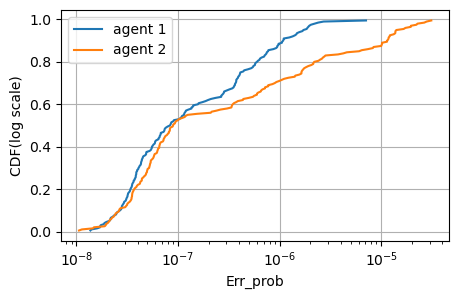

In [15]:
p_o =  1e-5
#rewards = np.array(epi_rewards)/J
err_prob = p_o*(np.power(10,-r1))
err_prob2 = p_o*(np.power(10,-r2))

def return_cdf(a):
    sorted_a = np.sort(a)
    cdf = np.arange(1, len(sorted_a) + 1) / len(sorted_a)
    return sorted_a, cdf

a, cdf = return_cdf(err_prob)
a2, cdf2 = return_cdf(err_prob2)
plt.figure(figsize= [5,3])
#plt.ylim(np.min(cdf2))
plt.semilogx(a, cdf, label = r'agent 1')
plt.semilogx(a2, cdf2, label = r'agent 2')
plt.grid()
plt.xlabel('Err_prob')
plt.ylabel('CDF(log scale)')
plt.legend()